# 12: Inference, Bootstrap, and Confidence Bands

This lesson is about uncertainty. DoubleML returns a treatment-effect point estimate; it also returns standard errors, confidence intervals, bootstrap-based joint intervals, and adjusted p-values for multiple testing.

The basic inference logic is asymptotic. Under regularity conditions, the orthogonal score behaves like an average of approximately mean-zero influence terms. That gives an approximate normal distribution for the estimator:

$$
\frac{\hat{\theta} - \theta_0}{\widehat{\mathrm{se}}(\hat{\theta})} \approx N(0, 1).
$$

From that approximation, DoubleML reports standard errors, t-statistics, p-values, and pointwise confidence intervals. But many applied analyses estimate more than one treatment effect. Once several effects are examined together, pointwise intervals can become too optimistic if they are read as a family-level statement. That is where multiplier bootstrap, joint intervals, and multiple-testing adjustment enter.

We use a synthetic multi-treatment PLR design with three treatment variables:

- `d_main`: a strong positive effect,
- `d_secondary`: a smaller positive effect,
- `d_null`: a true zero effect.

That mix lets us see how inference behaves for strong signals, moderate signals, and null effects. The key teaching goal is not to memorize one API call. The goal is to learn how to report uncertainty honestly:

1. Use standard errors and pointwise confidence intervals for individual effects.
2. Use bootstrap-based joint intervals when making simultaneous claims.
3. Use adjusted p-values when testing several effects at once.
4. Treat inference as conditional on the causal design and identifying assumptions.

Expected runtime: usually under one minute. The lesson runs one main multi-treatment DoubleML fit, several bootstrap calls, and a small coverage simulation.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use controlled semi-synthetic datasets with known nuisance functions or known treatment effects to study **Inference, Bootstrap, And Confidence Bands**. Double machine learning is easiest to understand when the data contain realistic nuisance structure but still give us a benchmark for the target parameter. That lets the lesson separate estimation error from identification failure.

Read each row as a unit with pre-treatment covariates, a treatment or instrument, and an outcome. The learner comparisons are experiments about orthogonalization, cross-fitting, overlap, sample splitting, and decision targets. The experiment treats uncertainty as an object to estimate and report directly. Resampling behavior is interpreted against the known design. The experiment treats uncertainty as an object to estimate and report directly. Intervals are judged by whether they communicate sampling variation around the target.

The estimators are causal only under the stated design assumptions. Flexible machine-learning nuisance models help with prediction bias, but they do not replace causal identification.


## Mathematical Foundation

<!-- math-foundation-note -->

Inference usually relies on the asymptotic approximation

$$
\sqrt n(\widehat\theta-\theta_0) \Rightarrow N(0,\sigma^2).
$$

A standard confidence interval is

$$
\widehat\theta \pm z_{1-\alpha/2}\widehat{se}(\widehat\theta).
$$

Bootstrap and confidence-band tools estimate uncertainty around scalar effects or effect functions, not uncertainty in nuisance prediction alone.





## Tutorial Workflow

#### Setup

The code below prepares the output folders, imports DoubleML and scientific Python tools, and applies a few narrow warning filters for known lesson-environment noise. The code remains visible so the workflow can be studied and rerun.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
import doubleml as dml
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.base import clone
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
NOTEBOOK_PREFIX = "12"
RANDOM_SEED = 42
TRUE_THETAS = {"d_main": 1.00, "d_secondary": 0.45, "d_null": 0.00}
TREATMENT_COLS = list(TRUE_THETAS.keys())
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
print(f"DoubleML version: {dml.__version__}")


The setup confirms the installed DoubleML version and where generated outputs will be saved. Every table and figure in this lesson uses prefix `12`.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Helper Functions

The helper functions below keep the tutorial code compact. They save outputs, build a DoubleML backend, compute nuisance prediction metrics, and format confidence intervals.

The inference helpers use transparent normal-theory formulas. DoubleML already computes these quantities, but writing them explicitly makes the connection between standard errors, z critical values, and interval width easier to see.


In [2]:
# Define reusable helpers for the Helper Functions section.
def save_table(df, filename):
    """
    Idea: Save a result table to the notebook table directory and return the same DataFrame for display.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Same table after writing it to the tutorial table directory.
    """
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    return path
def save_dataset(df, filename):
    """
    Idea: Write the constructed dataset to the tutorial output folder so later notebooks or cells can reuse it.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    filename : str
        Output filename used by the helper.
    
    Returns
    -------
    pd.DataFrame
        Same dataset after writing it to the tutorial dataset directory.
    """
    path = DATASET_DIR / filename
    df.to_csv(path, index=False)
    return path
def model_x_cols(df):
    """
    Idea: Select the covariate columns used by the model while excluding treatment, outcome, and oracle columns.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    list[str]
        Covariate column names used as model inputs after excluding treatment, outcome, and oracle fields.
    """
    excluded = {"unit_id", "outcome", "true_g", "true_m_main", "true_m_secondary", "true_m_null"}.union(TREATMENT_COLS)
    return [col for col in df.columns if col not in excluded]
def make_dml_data(df):
    """
    Idea: Construct the double machine learning data used in the Helper Functions section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    DoubleMLData
        DoubleMLData object configured with outcome, treatment, and covariate columns for the tutorial estimator.
    """
    return DoubleMLData(df, y_col="outcome", d_cols=TREATMENT_COLS, x_cols=model_x_cols(df))
def rmse_metric(y_true, y_pred):
    """
    Idea: Compute an RMSE value from a fitted learner and evaluation data.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Root mean squared prediction error for the fitted learner on evaluation data.
    """
    mask = ~np.isnan(y_true)
    return mean_squared_error(y_true[mask], y_pred[mask]) ** 0.5
def mae_metric(y_true, y_pred):
    """
    Idea: Compute mean absolute error from a fitted learner and evaluation data.
    
    Parameters
    ----------
    y_true : array-like
        Reference outcome, oracle value, or known target used for evaluation.
    y_pred : array-like
        Predicted outcome or estimated value being evaluated.
    
    Returns
    -------
    float
        Mean absolute prediction error for the fitted learner on evaluation data.
    """
    mask = ~np.isnan(y_true)
    return mean_absolute_error(y_true[mask], y_pred[mask])
def ci_from_coef_se(coef, se, level):
    """
    Idea: Turn a coefficient and standard error into a confidence interval at the requested level.
    
    Parameters
    ----------
    coef : object
        Estimated coefficient being converted into an interval or test statistic.
    se : object
        Standard error paired with the coefficient.
    level : object
        Confidence level used to construct the interval.
    
    Returns
    -------
    tuple[float, float, float]
        Lower bound, upper bound, and critical value for the requested confidence level.
    """
    alpha = 1 - level
    critical_value = stats.norm.ppf(1 - alpha / 2)
    return coef - critical_value * se, coef + critical_value * se, critical_value
def flatten_boot_t_stats(boot_t_stat, treatment_cols):
    """
    Idea: Flatten the flatten boot t stats output into a one-dimensional structure used by the inference display.
    
    Parameters
    ----------
    boot_t_stat : object
        Bootstrap t-statistics used for simultaneous inference.
    treatment_cols : list[str]
        Column names selected for `treatment`.
    
    Returns
    -------
    pd.DataFrame
        Long-format table of bootstrap t-statistics by repetition and coefficient.
    """
    rows = []
    n_boot, n_coef, n_rep = boot_t_stat.shape
    for boot_id in range(n_boot):
        for coef_id, treatment in enumerate(treatment_cols):
            for rep_id in range(n_rep):
                rows.append(
                    {
                        "boot_id": boot_id,
                        "treatment": treatment,
                        "rep_id": rep_id + 1,
                        "boot_t_stat": boot_t_stat[boot_id, coef_id, rep_id],
                    }
                )
    return pd.DataFrame(rows)


These helpers are reusable. The key one for this lesson is `ci_from_coef_se()`, which mirrors the pointwise normal interval logic that appears in the DoubleML summary.


### Inference Vocabulary

The vocabulary table clarifies what the lesson means by standard error, confidence interval, joint interval, and adjusted p-value. These terms are closely related, but they answer different reporting questions.


| term | meaning | reporting question |
| --- | --- | --- |
| Standard error | Estimated sampling variability of the treatment-effect estimator. | How noisy is this point estimate? |
| Pointwise confidence interval | Interval for one parameter using a marginal critical value. | What range is plausible for this one effect? |
| Multiplier bootstrap | Resamples score contributions through random multipliers to approximate estimator uncertainty. | How can we approximate the distribution of t-statistics without refitting nuisances many times? |
| Joint confidence interval | Simultaneous interval family designed to cover all selected parameters together. | What ranges are plausible if I discuss all effects as a family? |
| Adjusted p-value | P-value corrected for multiple testing across several hypotheses. | Which effects remain evidence-bearing after accounting for multiple looks? |


The distinction between pointwise and joint uncertainty is central. A pointwise 95% interval is not the same thing as a 95% statement about several intervals at once.


### Synthetic Multi-Treatment PLR Data

We generate a linear nuisance design so the inference examples are clean. The outcome has three treatment variables: two have true nonzero effects and one has a true zero effect. The nuisance functions depend on observed controls, so adjustment is still necessary.

The data-generating process is simple enough for Ridge learners to perform well. This lesson is about inference mechanics, not learner complexity.


In [3]:
rng = np.random.default_rng(RANDOM_SEED)
n_obs = 900
n_controls = 12
x_array = rng.normal(size=(n_obs, n_controls))
inference_df = pd.DataFrame(x_array, columns=[f"x{i:02d}" for i in range(n_controls)])
inference_df.insert(0, "unit_id", np.arange(n_obs))
inference_df["true_m_main"] = 0.60 * inference_df["x00"] - 0.40 * inference_df["x01"] + 0.20 * inference_df["x04"]
inference_df["true_m_secondary"] = -0.30 * inference_df["x00"] + 0.50 * inference_df["x03"] + 0.25 * inference_df["x05"]
inference_df["true_m_null"] = 0.20 * inference_df["x06"] - 0.20 * inference_df["x08"] + 0.20 * inference_df["x09"]
inference_df["true_g"] = (
    0.80 * inference_df["x00"]
    + 0.50 * inference_df["x01"]
    - 0.40 * inference_df["x02"]
    + 0.30 * inference_df["x03"]
    + 0.25 * inference_df["x07"]
)
inference_df["d_main"] = inference_df["true_m_main"] + rng.normal(scale=1.00, size=n_obs)
inference_df["d_secondary"] = inference_df["true_m_secondary"] + rng.normal(scale=1.00, size=n_obs)
inference_df["d_null"] = inference_df["true_m_null"] + rng.normal(scale=1.00, size=n_obs)
inference_df["outcome"] = (
    TRUE_THETAS["d_main"] * inference_df["d_main"]
    + TRUE_THETAS["d_secondary"] * inference_df["d_secondary"]
    + TRUE_THETAS["d_null"] * inference_df["d_null"]
    + inference_df["true_g"]
    + rng.normal(scale=1.00, size=n_obs)
)
save_dataset(inference_df, f"{NOTEBOOK_PREFIX}_synthetic_multitreatment_plr_data.csv")
inference_df.head()


,unit_id,x00,x01,x02,x03,x04,x05,x06,x07,x08,x09,x10,x11,true_m_main,true_m_secondary,true_m_null,true_g,d_main,d_secondary,d_null,outcome
0,0,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,0.208617,0.053322,-0.141680,-0.373290,0.235268,-0.542936,1.576123,-0.730007
1,1,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,-0.337528,-0.689176,0.076477,0.159172,-0.893095,0.931589,-1.362971,0.708280
2,2,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.033597,0.418926,0.368024,-0.723623,-0.551443,-0.680935,0.923762,-1.376645
3,3,-0.113947,-0.840156,-0.824481,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.416345,0.495269,-0.112701,0.071774,-0.146882,1.181661,0.686230,0.620283
4,4,0.678914,0.067579,0.289119,0.631288,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,0.088885,0.032052,0.259942,0.490940,-0.384918,0.556281,-0.077955,0.218237


The first rows show the observed controls, oracle nuisance columns, treatments, and outcome. The oracle columns are present only for simulation documentation and are excluded from the DoubleML control matrix.





## Diagnostics and Interpretation

#### Data Dictionary and Audit

Inference should be reported after the design is clear. This audit records the treatment roles, true simulated effects, and basic confounding correlations.


In [4]:
field_dictionary = pd.DataFrame(
    [
        {"column": "unit_id", "role": "identifier", "description": "Synthetic row identifier; excluded from modeling."},
        {"column": "x00-x11", "role": "observed controls", "description": "Numeric pre-treatment controls."},
        {"column": "true_m_*", "role": "oracle only", "description": "True treatment nuisance functions used only for simulation documentation."},
        {"column": "true_g", "role": "oracle only", "description": "True outcome nuisance component used only for simulation documentation."},
        {"column": "d_main", "role": "treatment", "description": "Treatment with true effect 1.00."},
        {"column": "d_secondary", "role": "treatment", "description": "Treatment with true effect 0.45."},
        {"column": "d_null", "role": "treatment", "description": "Treatment with true effect 0.00."},
        {"column": "outcome", "role": "outcome", "description": "Continuous outcome."},
    ]
)
audit_rows = []
for treatment in TREATMENT_COLS:
    nuisance_col = f"true_m_{treatment.replace('d_', '')}"
    audit_rows.append(
        {
            "treatment": treatment,
            "true_theta": TRUE_THETAS[treatment],
            "treatment_mean": inference_df[treatment].mean(),
            "treatment_sd": inference_df[treatment].std(),
            "corr_treatment_true_g": inference_df[treatment].corr(inference_df["true_g"]),
            "corr_treatment_own_nuisance": inference_df[treatment].corr(inference_df[nuisance_col]),
        }
    )
data_audit = pd.DataFrame(audit_rows)
overall_audit = pd.DataFrame(
    {
        "n_rows": [len(inference_df)],
        "n_controls": [len(model_x_cols(inference_df))],
        "n_treatments": [len(TREATMENT_COLS)],
        "missing_cells": [int(inference_df.isna().sum().sum())],
    }
)
save_table(field_dictionary, f"{NOTEBOOK_PREFIX}_field_dictionary.csv")
save_table(data_audit, f"{NOTEBOOK_PREFIX}_treatment_audit.csv")
save_table(overall_audit, f"{NOTEBOOK_PREFIX}_overall_data_audit.csv")
display(field_dictionary)
display(overall_audit)
display(data_audit)


,column,role,description
0,unit_id,identifier,Synthetic row identifier; excluded from modeling.
1,x00-x11,observed controls,Numeric pre-treatment controls.
2,true_m_*,oracle only,True treatment nuisance functions used only for simulation documentation.
3,true_g,oracle only,True outcome nuisance component used only for simulation documentation.
4,d_main,treatment,Treatment with true effect 1.00.
5,d_secondary,treatment,Treatment with true effect 0.45.
6,d_null,treatment,Treatment with true effect 0.00.
7,outcome,outcome,Continuous outcome.


,n_rows,n_controls,n_treatments,missing_cells
0,900,12,3,0


,treatment,true_theta,treatment_mean,treatment_sd,corr_treatment_true_g,corr_treatment_own_nuisance
0,d_main,1.00,0.001838,1.232587,0.157730,0.566644
1,d_secondary,0.45,-0.023836,1.149815,-0.164968,0.548663
2,d_null,0.00,-0.010946,1.066717,0.007058,0.312512


The audit shows that treatments are related to their nuisance functions and, for some treatments, to outcome-relevant structure. That is why causal inference needs adjustment before uncertainty reporting.




### Inference Workflow Diagram

This diagram shows the inference stack. The point estimate and standard error come from the fitted orthogonal score. Bootstrap then approximates the distribution of score-based t-statistics, which supports joint intervals and Romano-Wolf-style p-value adjustment.


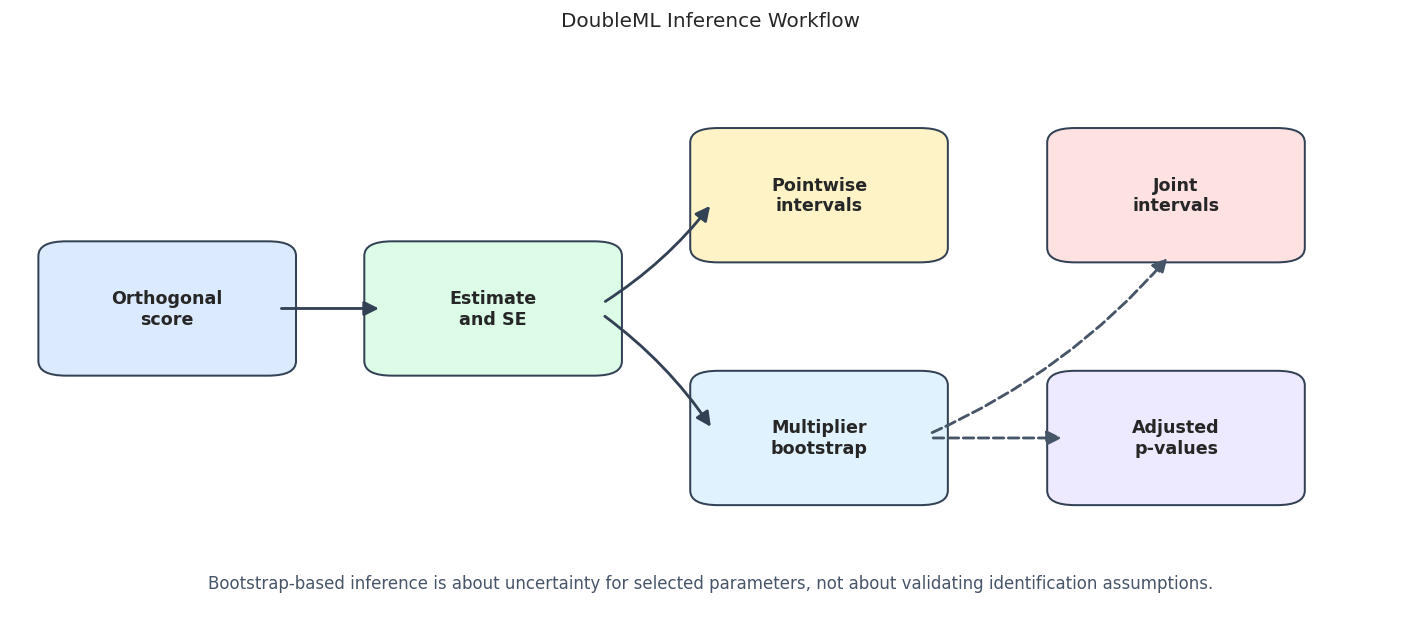

In [5]:
# Define reusable helpers for the Inference Workflow Diagram section.
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
nodes = {
    "score": {"xy": (0.10, 0.58), "label": "Orthogonal\nscore", "color": "#dbeafe"},
    "estimate": {"xy": (0.31, 0.58), "label": "Estimate\nand SE", "color": "#dcfce7"},
    "pointwise": {"xy": (0.52, 0.72), "label": "Pointwise\nintervals", "color": "#fef3c7"},
    "bootstrap": {"xy": (0.52, 0.42), "label": "Multiplier\nbootstrap", "color": "#e0f2fe"},
    "joint": {"xy": (0.75, 0.72), "label": "Joint\nintervals", "color": "#fee2e2"},
    "adjust": {"xy": (0.75, 0.42), "label": "Adjusted\np-values", "color": "#ede9fe"},
}
fig, ax = plt.subplots(figsize=(12, 5.4))
ax.set_axis_off()
ax.set_xlim(0.0, 0.90)
ax.set_ylim(0.20, 0.90)
box_w, box_h = 0.13, 0.13
def anchor(name, side):
    """
    Idea: Return the plotting anchor point for a named node in the diagram.
    
    Parameters
    ----------
    name : str
        Short name used for the scenario label.
    side : object
        Endpoint side used to place an arrow or edge on the correct part of a node.
    
    Returns
    -------
    tuple[float, float] or np.ndarray
        Coordinate of the requested side of a plotted node.
    """
    x, y = nodes[name]["xy"]
    offsets = {"left": (-box_w / 2, 0), "right": (box_w / 2, 0), "top": (0, box_h / 2), "bottom": (0, -box_h / 2)}
    dx, dy = offsets[side]
    return (x + dx, y + dy)
def draw_arrow(start, end, color="#334155", style="solid", rad=0.0):
    """
    Idea: Draw a routed arrow between diagram nodes while keeping the arrowhead visible.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    style : object
        Plotting style that determines how the curve, marker, or annotation is drawn.
    rad : float
        Curvature parameter for the plotted arrow.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.7,
        color=color,
        linestyle=style,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=8,
        shrinkB=8,
        zorder=5,
    )
    ax.add_patch(arrow)
for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.018",
        facecolor=spec["color"],
        edgecolor="#334155",
        linewidth=1.2,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=4)
draw_arrow(anchor("score", "right"), anchor("estimate", "left"))
draw_arrow(anchor("estimate", "right"), anchor("pointwise", "left"), rad=0.10)
draw_arrow(anchor("estimate", "right"), anchor("bootstrap", "left"), rad=-0.10)
draw_arrow(anchor("bootstrap", "right"), anchor("joint", "bottom"), color="#475569", style="dashed", rad=0.12)
draw_arrow(anchor("bootstrap", "right"), anchor("adjust", "left"), color="#475569", style="dashed")
ax.text(
    0.45,
    0.24,
    "Bootstrap-based inference is about uncertainty for selected parameters, not about validating identification assumptions.",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)
ax.set_title("DoubleML Inference Workflow", pad=14)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_inference_workflow.png", bbox_inches="tight")
plt.show()


The workflow separates marginal inference from simultaneous inference. Both are useful, but they answer different questions.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Fit a Multi-Treatment DoubleMLPLR Model

We fit one PLR model with three treatment columns. DoubleML estimates one coefficient per treatment and returns a summary table with standard errors, t-statistics, p-values, and pointwise intervals.

The learner is a scaled RidgeCV pipeline. Scaling is inside the pipeline so preprocessing is done inside the cross-fitting folds rather than globally leaking information.


In [6]:
base_learner = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 15))),
    ]
)
dml_data = make_dml_data(inference_df)
inference_model = DoubleMLPLR(
    dml_data,
    ml_l=clone(base_learner),
    ml_m=clone(base_learner),
    n_folds=5,
    n_rep=3,
)
fit_start = time.perf_counter()
inference_model.fit()
fit_runtime = time.perf_counter() - fit_start
print(f"Fit runtime: {fit_runtime:.2f} seconds")
display(inference_model.summary)


Fit runtime: 0.28 seconds


,coef,std err,t,P>|t|,2.5 %,97.5 %
d_main,0.993459,0.033845,29.353621,2.148287e-189,0.927125,1.059793
d_secondary,0.464160,0.032633,14.223840,6.517647e-46,0.399850,0.528119
d_null,-0.022710,0.033728,-0.673319,5.007441e-01,-0.088816,0.043396


The summary table is the default inference view. It is pointwise: each row is interpreted as a separate treatment-effect estimate unless we add joint inference or p-value adjustment.


#### Standard Error and Pointwise Inference Table

The code below converts the DoubleML summary into an explicit reporting table and adds the known true effect from the simulation. In real data, the true effect column would not exist; it is included here only for learning.


In [7]:
standard_inference = inference_model.summary.reset_index().rename(columns={"index": "treatment"})
standard_inference["true_theta"] = standard_inference["treatment"].map(TRUE_THETAS)
standard_inference["bias_vs_true"] = standard_inference["coef"] - standard_inference["true_theta"]
standard_inference["covers_true_pointwise_95"] = (
    (standard_inference["2.5 %"] <= standard_inference["true_theta"])
    & (standard_inference["97.5 %"] >= standard_inference["true_theta"])
)
nuisance_rmse = inference_model.evaluate_learners(metric=rmse_metric)
nuisance_mae = inference_model.evaluate_learners(metric=mae_metric)
nuisance_quality = pd.DataFrame(
    [
        {
            "nuisance": name,
            "rmse_mean_across_treatments": float(np.nanmean(values)),
            "mae_mean_across_treatments": float(np.nanmean(nuisance_mae[name])),
        }
        for name, values in nuisance_rmse.items()
    ]
)
save_table(standard_inference, f"{NOTEBOOK_PREFIX}_standard_inference_summary.csv")
save_table(nuisance_quality, f"{NOTEBOOK_PREFIX}_nuisance_quality.csv")
display(standard_inference)
display(nuisance_quality)


,treatment,coef,std err,t,P>|t|,2.5 %,97.5 %,true_theta,bias_vs_true,covers_true_pointwise_95
0,d_main,0.993459,0.033845,29.353621,2.148287e-189,0.927125,1.059793,1.00,-0.006541,True
1,d_secondary,0.464160,0.032633,14.223840,6.517647e-46,0.399850,0.528119,0.45,0.014160,True
2,d_null,-0.022710,0.033728,-0.673319,5.007441e-01,-0.088816,0.043396,0.00,-0.022710,True


,nuisance,rmse_mean_across_treatments,mae_mean_across_treatments
0,ml_l,1.208594,0.961556
1,ml_m,1.008989,0.801563


The strong and moderate effects are clearly separated from zero, while the null effect is not. The nuisance-quality table records that inference was built from cross-fitted nuisance predictions rather than in-sample fits.




### Confidence Levels and Interval Widths

Confidence intervals widen as the confidence level increases. The code below computes 90%, 95%, and 99% pointwise intervals manually from the coefficient and standard error.


In [8]:
ci_level_rows = []
for treatment, coef, se in zip(TREATMENT_COLS, inference_model.coef, inference_model.se):
    for level in [0.90, 0.95, 0.99]:
        lower, upper, critical_value = ci_from_coef_se(coef, se, level)
        ci_level_rows.append(
            {
                "treatment": treatment,
                "level": level,
                "critical_value": critical_value,
                "coef": coef,
                "se": se,
                "ci_lower": lower,
                "ci_upper": upper,
                "ci_width": upper - lower,
                "true_theta": TRUE_THETAS[treatment],
                "covers_true": lower <= TRUE_THETAS[treatment] <= upper,
            }
        )
ci_levels = pd.DataFrame(ci_level_rows)
save_table(ci_levels, f"{NOTEBOOK_PREFIX}_pointwise_confidence_levels.csv")
display(ci_levels)


,treatment,level,critical_value,coef,se,ci_lower,ci_upper,ci_width,true_theta,covers_true
0,d_main,0.90,1.644854,0.993459,0.033845,0.937790,1.049128,0.111339,1.00,True
1,d_main,0.95,1.959964,0.993459,0.033845,0.927125,1.059793,0.132668,1.00,True
2,d_main,0.99,2.575829,0.993459,0.033845,0.906281,1.080637,0.174355,1.00,True
3,d_secondary,0.90,1.644854,0.464160,0.032633,0.410484,0.517836,0.107352,0.45,True
4,d_secondary,0.95,1.959964,0.464160,0.032633,0.400202,0.528119,0.127917,0.45,True
5,d_secondary,0.99,2.575829,0.464160,0.032633,0.380104,0.548216,0.168112,0.45,True
6,d_null,0.90,1.644854,-0.022710,0.033728,-0.078188,0.032768,0.110956,0.00,True
7,d_null,0.95,1.959964,-0.022710,0.033728,-0.088816,0.043396,0.132212,0.00,True
8,d_null,0.99,2.575829,-0.022710,0.033728,-0.109588,0.064168,0.173756,0.00,True


The table shows the mechanical relationship between confidence level and interval width. Higher confidence requires a larger critical value, so the interval becomes wider.




#### Confidence Level Plot

The plot below shows the same idea visually. Each treatment receives three intervals, one per confidence level.


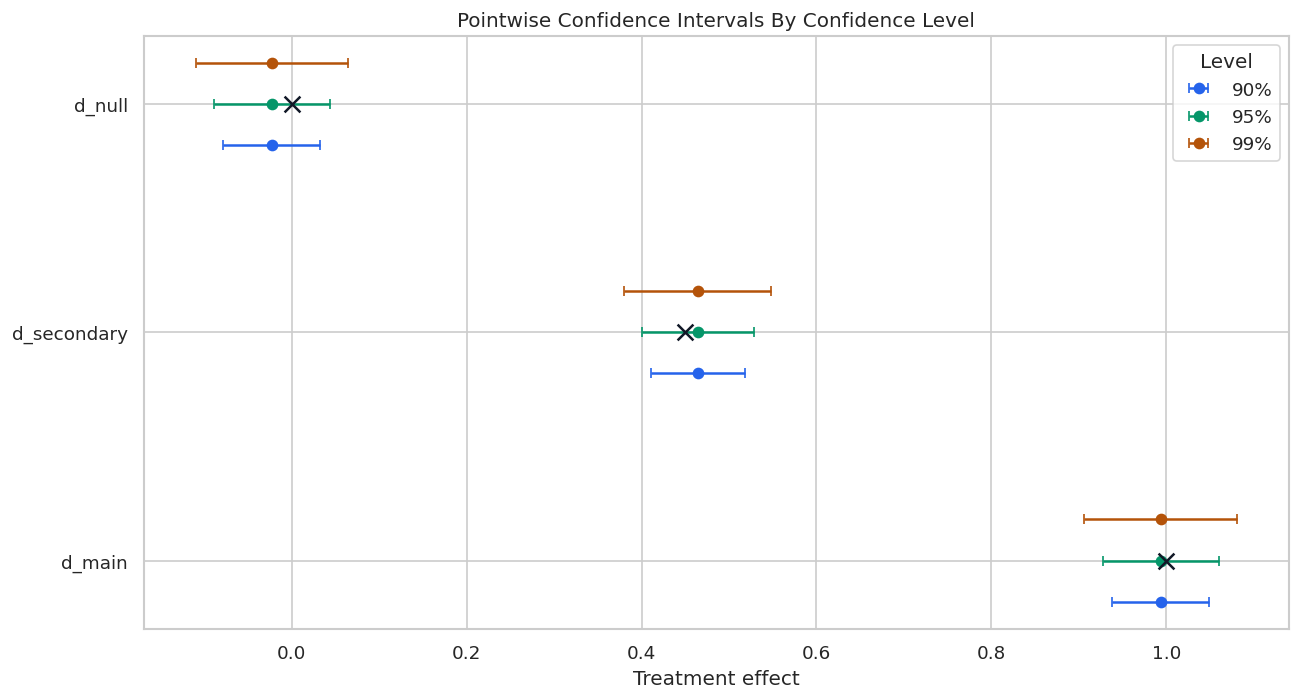

In [9]:
# Build and label the diagnostic visualization for the Confidence Level Plot section.
fig, ax = plt.subplots(figsize=(11, 6))
level_offsets = {0.90: -0.18, 0.95: 0.00, 0.99: 0.18}
y_positions = {treatment: idx for idx, treatment in enumerate(TREATMENT_COLS)}
colors = {0.90: "#2563eb", 0.95: "#059669", 0.99: "#b45309"}
for _, row in ci_levels.iterrows():
    y = y_positions[row["treatment"]] + level_offsets[row["level"]]
    ax.errorbar(
        x=row["coef"],
        y=y,
        xerr=[[row["coef"] - row["ci_lower"]], [row["ci_upper"] - row["coef"]]],
        fmt="o",
        color=colors[row["level"]],
        ecolor=colors[row["level"]],
        capsize=3,
        label=f"{int(row['level'] * 100)}%" if row["treatment"] == TREATMENT_COLS[0] else None,
    )
for treatment, true_value in TRUE_THETAS.items():
    ax.scatter(true_value, y_positions[treatment], marker="x", s=90, color="#111827", zorder=5)
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(TREATMENT_COLS)
ax.set_title("Pointwise Confidence Intervals By Confidence Level")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("")
ax.legend(title="Level", loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_confidence_levels.png", bbox_inches="tight")
plt.show()


The x markers are the known true effects from the simulation. In applied work those markers do not exist, so the interval itself must be interpreted as an uncertainty statement under the design assumptions.


### Multiplier Bootstrap

DoubleML's `bootstrap()` method draws random multipliers for the estimated score contributions. This approximates the distribution of t-statistics without refitting all nuisance models for every bootstrap draw.

We use 800 bootstrap replications here. That is enough for a stable teaching plot while remaining fast.


In [10]:
np.random.seed(RANDOM_SEED)
bootstrap_start = time.perf_counter()
inference_model.bootstrap(method="normal", n_rep_boot=800)
bootstrap_runtime = time.perf_counter() - bootstrap_start
boot_stats = flatten_boot_t_stats(inference_model.boot_t_stat, TREATMENT_COLS)
boot_max_abs = (
    boot_stats.groupby(["boot_id", "rep_id"])["boot_t_stat"]
    .apply(lambda values: np.max(np.abs(values)))
    .reset_index(name="max_abs_t")
)
joint_critical_95 = boot_max_abs["max_abs_t"].quantile(0.95)
bootstrap_summary = pd.DataFrame(
    {
        "method": ["normal"],
        "n_rep_boot": [800],
        "bootstrap_runtime_seconds": [bootstrap_runtime],
        "joint_critical_95": [joint_critical_95],
    }
)
save_table(bootstrap_summary, f"{NOTEBOOK_PREFIX}_bootstrap_summary.csv")
save_table(boot_stats, f"{NOTEBOOK_PREFIX}_bootstrap_t_statistics.csv")
save_table(boot_max_abs, f"{NOTEBOOK_PREFIX}_bootstrap_max_abs_t.csv")
display(bootstrap_summary)
display(boot_stats.head())


,method,n_rep_boot,bootstrap_runtime_seconds,joint_critical_95
0,normal,800,0.039017,2.346278


,boot_id,treatment,rep_id,boot_t_stat
0,0,d_main,1,0.214724
1,0,d_main,2,1.429037
2,0,d_main,3,1.054318
3,0,d_secondary,1,-0.558725
4,0,d_secondary,2,1.150842


The bootstrap stores t-statistics for each treatment and each repeated sample split. The maximum absolute t-statistic distribution is what makes simultaneous inference wider than pointwise inference.




#### Bootstrap T-Statistic Distribution

This figure shows the bootstrap t-statistic distribution by treatment, plus the distribution of the maximum absolute t-statistic used for joint intervals.


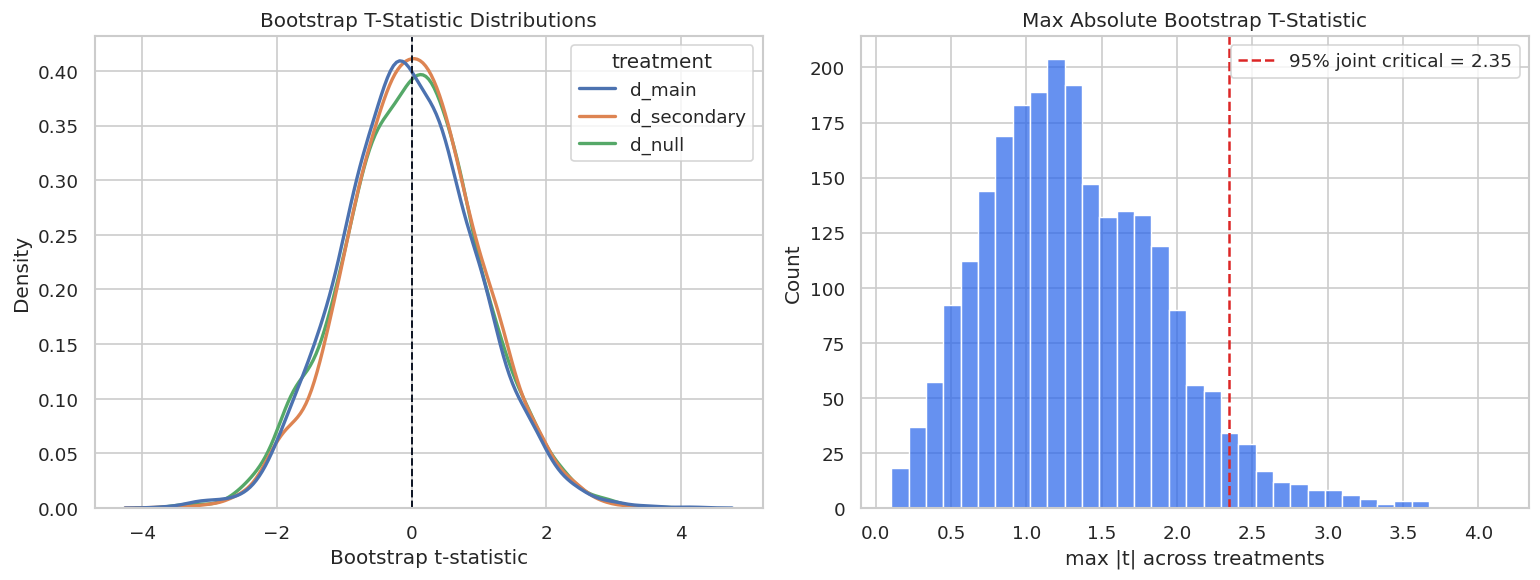

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.kdeplot(
    data=boot_stats,
    x="boot_t_stat",
    hue="treatment",
    common_norm=False,
    linewidth=2,
    ax=axes[0],
)
axes[0].axvline(0, color="#111827", linestyle="--", linewidth=1.2)
axes[0].set_title("Bootstrap T-Statistic Distributions")
axes[0].set_xlabel("Bootstrap t-statistic")
axes[0].set_ylabel("Density")
sns.histplot(data=boot_max_abs, x="max_abs_t", bins=35, color="#2563eb", alpha=0.70, ax=axes[1])
axes[1].axvline(joint_critical_95, color="#dc2626", linestyle="--", linewidth=1.5, label=f"95% joint critical = {joint_critical_95:.2f}")
axes[1].set_title("Max Absolute Bootstrap T-Statistic")
axes[1].set_xlabel("max |t| across treatments")
axes[1].set_ylabel("Count")
axes[1].legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_bootstrap_t_distributions.png", bbox_inches="tight")
plt.show()


The max-statistic distribution has a larger critical value than the usual 1.96 pointwise normal cutoff. That is why joint intervals are wider.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->


#### Pointwise versus Joint Confidence Intervals

Now we compare pointwise 95% confidence intervals with bootstrap-based joint 95% confidence intervals. Joint intervals are appropriate when reporting several effects as a family and wanting simultaneous coverage.


In [12]:
pointwise_ci = inference_model.confint(joint=False, level=0.95).reset_index().rename(columns={"index": "treatment", "2.5 %": "pointwise_lower", "97.5 %": "pointwise_upper"})
joint_ci = inference_model.confint(joint=True, level=0.95).reset_index().rename(columns={"index": "treatment", "2.5 %": "joint_lower", "97.5 %": "joint_upper"})
ci_comparison = standard_inference[["treatment", "coef", "std err", "true_theta"]].merge(pointwise_ci, on="treatment").merge(joint_ci, on="treatment")
ci_comparison["pointwise_width"] = ci_comparison["pointwise_upper"] - ci_comparison["pointwise_lower"]
ci_comparison["joint_width"] = ci_comparison["joint_upper"] - ci_comparison["joint_lower"]
ci_comparison["joint_width_ratio"] = ci_comparison["joint_width"] / ci_comparison["pointwise_width"]
ci_comparison["pointwise_covers_true"] = (ci_comparison["pointwise_lower"] <= ci_comparison["true_theta"]) & (ci_comparison["pointwise_upper"] >= ci_comparison["true_theta"])
ci_comparison["joint_covers_true"] = (ci_comparison["joint_lower"] <= ci_comparison["true_theta"]) & (ci_comparison["joint_upper"] >= ci_comparison["true_theta"])
save_table(ci_comparison, f"{NOTEBOOK_PREFIX}_pointwise_vs_joint_ci.csv")
display(ci_comparison)


,treatment,coef,std err,true_theta,pointwise_lower,pointwise_upper,joint_lower,joint_upper,pointwise_width,joint_width,joint_width_ratio,pointwise_covers_true,joint_covers_true
0,d_main,0.993459,0.033845,1.00,0.927125,1.059793,0.911843,1.074356,0.132668,0.162513,1.224960,True,True
1,d_secondary,0.464160,0.032633,0.45,0.399850,0.528119,0.387054,0.540507,0.128269,0.153453,1.196335,True,True
2,d_null,-0.022710,0.033728,0.00,-0.088816,0.043396,-0.099680,0.058226,0.132212,0.157906,1.194334,True,True


The joint intervals are wider because they are calibrated to cover the collection of effects together. This is the right trade-off when the write-up makes simultaneous claims.


#### Pointwise versus Joint Interval Plot

The plot below overlays the two interval types. Pointwise intervals are blue; joint intervals are orange. The black x marks the known true effect.


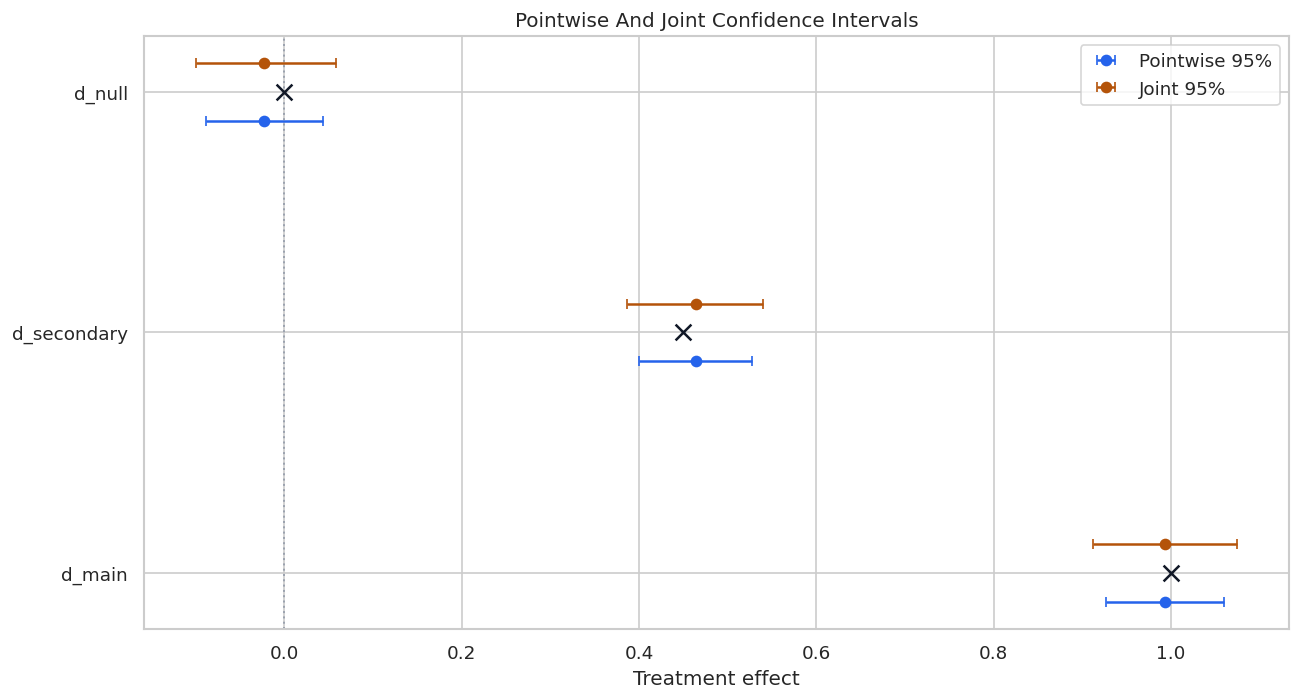

In [13]:
# Build and label the diagnostic visualization for the Pointwise Versus Joint Interval Plot section.
fig, ax = plt.subplots(figsize=(11, 6))
y_positions = {treatment: idx for idx, treatment in enumerate(TREATMENT_COLS)}
for _, row in ci_comparison.iterrows():
    y_base = y_positions[row["treatment"]]
    ax.errorbar(
        x=row["coef"],
        y=y_base - 0.12,
        xerr=[[row["coef"] - row["pointwise_lower"]], [row["pointwise_upper"] - row["coef"]]],
        fmt="o",
        color="#2563eb",
        ecolor="#2563eb",
        capsize=3,
        label="Pointwise 95%" if row["treatment"] == TREATMENT_COLS[0] else None,
    )
    ax.errorbar(
        x=row["coef"],
        y=y_base + 0.12,
        xerr=[[row["coef"] - row["joint_lower"]], [row["joint_upper"] - row["coef"]]],
        fmt="o",
        color="#b45309",
        ecolor="#b45309",
        capsize=3,
        label="Joint 95%" if row["treatment"] == TREATMENT_COLS[0] else None,
    )
    ax.scatter(row["true_theta"], y_base, marker="x", s=90, color="#111827", zorder=6)
ax.axvline(0, color="#9ca3af", linestyle=":", linewidth=1.2)
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(TREATMENT_COLS)
ax.set_title("Pointwise And Joint Confidence Intervals")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pointwise_vs_joint_ci.png", bbox_inches="tight")
plt.show()


The null treatment interval includes zero under both approaches. The nonzero treatments remain clearly positive, even after joint calibration.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Bootstrap Method Comparison

DoubleML supports several multiplier bootstrap methods: `normal`, `Bayes`, and `wild`. In many well-behaved examples they give similar results, but comparing them is a useful robustness check.


In [14]:
bootstrap_method_rows = []
for method in ["normal", "Bayes", "wild"]:
    np.random.seed(RANDOM_SEED)
    inference_model.bootstrap(method=method, n_rep_boot=500)
    method_joint_ci = inference_model.confint(joint=True, level=0.95).reset_index().rename(columns={"index": "treatment", "2.5 %": "joint_lower", "97.5 %": "joint_upper"})
    method_joint_ci["method"] = method
    method_joint_ci["joint_width"] = method_joint_ci["joint_upper"] - method_joint_ci["joint_lower"]
    bootstrap_method_rows.append(method_joint_ci)
bootstrap_method_comparison = pd.concat(bootstrap_method_rows, ignore_index=True)
save_table(bootstrap_method_comparison, f"{NOTEBOOK_PREFIX}_bootstrap_method_comparison.csv")
display(bootstrap_method_comparison)
# Restore the normal bootstrap for the p-value adjustment sections below.
np.random.seed(RANDOM_SEED)
inference_model.bootstrap(method="normal", n_rep_boot=800)


,treatment,joint_lower,joint_upper,method,joint_width
0,d_main,0.914653,1.072265,normal,0.157612
1,d_secondary,0.386598,0.537878,normal,0.151280
2,d_null,-0.099003,0.055425,normal,0.154428
3,d_main,0.912398,1.074520,Bayes,0.162123
4,d_secondary,0.386434,0.540265,Bayes,0.153831
5,d_null,-0.103896,0.059080,Bayes,0.162976
6,d_main,0.912760,1.074159,wild,0.161399
7,d_secondary,0.386619,0.539921,wild,0.153303
8,d_null,-0.101136,0.057312,wild,0.158448


The methods produce similar joint intervals in this clean synthetic design. Bigger differences would be a signal to inspect sample size, score behavior, and model stability.




#### Multiple Testing Adjustment

When testing several effects, unadjusted p-values answer each test separately. Adjusted p-values account for the fact that several hypotheses are being examined. DoubleML supports Romano-Wolf adjustment through the bootstrap, and also methods such as Holm and Bonferroni through statsmodels.


In [15]:
romano_wolf = inference_model.p_adjust(method="romano-wolf").reset_index().rename(columns={"index": "treatment", "pval": "romano_wolf_pval"})
holm = inference_model.p_adjust(method="holm").reset_index().rename(columns={"index": "treatment", "pval": "holm_pval"})
bonferroni = inference_model.p_adjust(method="bonferroni").reset_index().rename(columns={"index": "treatment", "pval": "bonferroni_pval"})
pvalue_comparison = standard_inference[["treatment", "coef", "P>|t|", "true_theta"]].rename(columns={"P>|t|": "pointwise_pval"})
pvalue_comparison = pvalue_comparison.merge(romano_wolf[["treatment", "romano_wolf_pval"]], on="treatment")
pvalue_comparison = pvalue_comparison.merge(holm[["treatment", "holm_pval"]], on="treatment")
pvalue_comparison = pvalue_comparison.merge(bonferroni[["treatment", "bonferroni_pval"]], on="treatment")
save_table(pvalue_comparison, f"{NOTEBOOK_PREFIX}_adjusted_pvalue_comparison.csv")
display(pvalue_comparison)


,treatment,coef,pointwise_pval,true_theta,romano_wolf_pval,holm_pval,bonferroni_pval
0,d_main,0.993459,2.148287e-189,1.00,0.000,0.000000,0.0
1,d_secondary,0.464160,6.517647e-46,0.45,0.000,0.000000,0.0
2,d_null,-0.022710,5.007441e-01,0.00,0.505,0.500744,1.0


The two true nonzero effects remain significant after adjustment, while the null treatment remains non-significant. That is the behavior we hope to see in this teaching simulation.


#### Adjusted P-Value Plot

The plot below shows pointwise and adjusted p-values on a log scale. The dashed line marks 0.05.


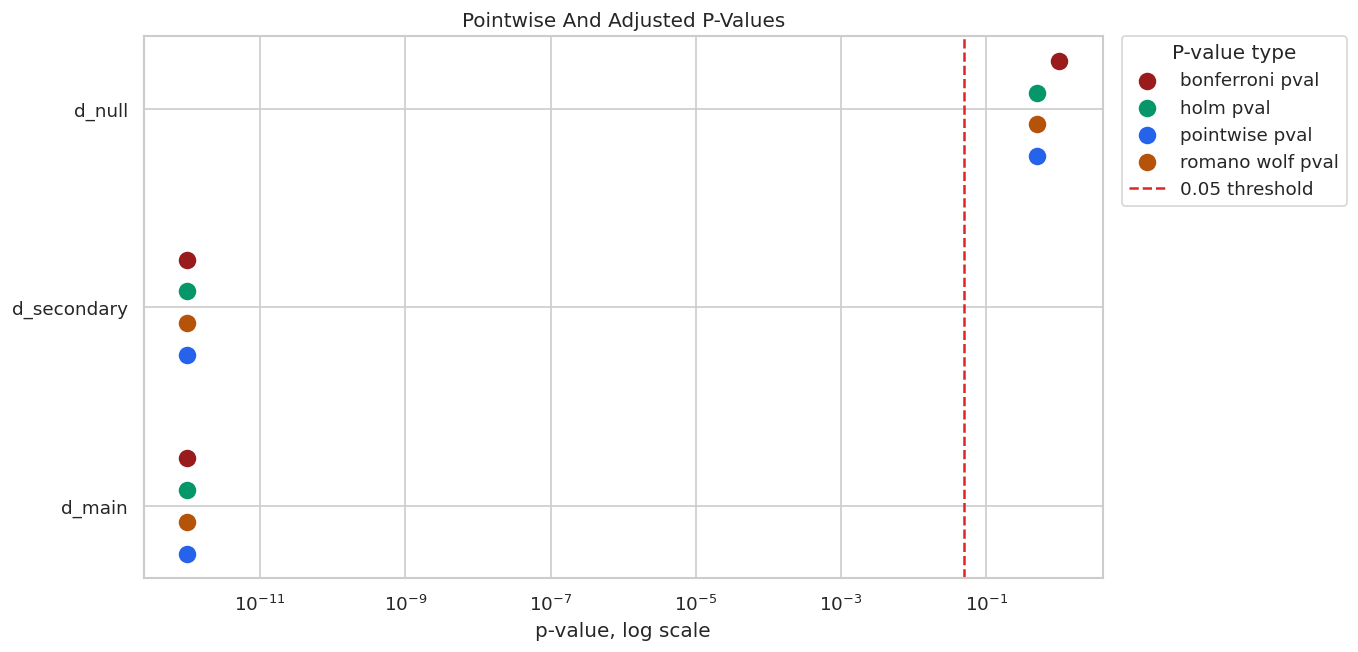

In [16]:
# Build and label the diagnostic visualization for the Adjusted P-Value Plot section.
pvalue_plot = pvalue_comparison.melt(
    id_vars="treatment",
    value_vars=["pointwise_pval", "romano_wolf_pval", "holm_pval", "bonferroni_pval"],
    var_name="pvalue_type",
    value_name="pvalue",
)
pvalue_plot["pvalue_for_plot"] = pvalue_plot["pvalue"].clip(lower=1e-12)
pvalue_offsets = {
    "pointwise_pval": -0.24,
    "romano_wolf_pval": -0.08,
    "holm_pval": 0.08,
    "bonferroni_pval": 0.24,
}
pvalue_colors = {
    "pointwise_pval": "#2563eb",
    "romano_wolf_pval": "#b45309",
    "holm_pval": "#059669",
    "bonferroni_pval": "#991b1b",
}
y_positions = {treatment: idx for idx, treatment in enumerate(TREATMENT_COLS)}
fig, ax = plt.subplots(figsize=(11.5, 5.6))
for pvalue_type, group in pvalue_plot.groupby("pvalue_type"):
    ax.scatter(
        group["pvalue_for_plot"],
        [y_positions[treatment] + pvalue_offsets[pvalue_type] for treatment in group["treatment"]],
        s=90,
        color=pvalue_colors[pvalue_type],
        label=pvalue_type.replace("_", " "),
    )
ax.axvline(0.05, color="#dc2626", linestyle="--", linewidth=1.5, label="0.05 threshold")
ax.set_xscale("log")
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(TREATMENT_COLS)
ax.set_title("Pointwise And Adjusted P-Values")
ax.set_xlabel("p-value, log scale")
ax.set_ylabel("")
ax.legend(title="P-value type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_adjusted_pvalues.png", bbox_inches="tight")
plt.show()


The log scale makes tiny p-values visible while still showing the null treatment near the non-significant region. Adjustment matters most when there are several borderline effects.


#### Small Coverage Simulation

This short simulation repeats a simple single-treatment PLR design several times and checks whether the pointwise 95% confidence interval covers the known true effect. It is small and should be read as a teaching sketch, not a formal Monte Carlo study.

A real simulation study would use many more repetitions, multiple sample sizes, and a fixed analysis plan.


In [17]:
# Define reusable helpers for the Small Coverage Simulation section.
def simulate_single_effect_dataset(seed, n_obs=350, n_controls=8, true_theta=0.80):
    """
    Idea: Simulate the single effect dataset scenario so the notebook can study a known causal or statistical failure mode.
    
    Parameters
    ----------
    seed : int
        Random seed used to make generation or resampling reproducible.
    n_obs : int
        Number of observations generated for the experiment.
    n_controls : object
        Number of control covariates included in the simulated design.
    true_theta : object
        Oracle treatment-effect value used as the synthetic benchmark.
    
    Returns
    -------
    pd.DataFrame or dict
        Named df object assembled by simulate single effect dataset.
    """
    rng_local = np.random.default_rng(seed)
    x = rng_local.normal(size=(n_obs, n_controls))
    df = pd.DataFrame(x, columns=[f"x{i}" for i in range(n_controls)])
    treatment_nuisance = 0.50 * df["x0"] - 0.30 * df["x1"] + 0.25 * df["x2"]
    outcome_nuisance = 0.60 * df["x0"] + 0.35 * df["x3"] - 0.25 * df["x4"]
    df["treatment"] = treatment_nuisance + rng_local.normal(size=n_obs)
    df["outcome"] = true_theta * df["treatment"] + outcome_nuisance + rng_local.normal(size=n_obs)
    return df
coverage_rows = []
coverage_true_theta = 0.80
coverage_learner = Ridge(alpha=1.0)
for sim_id in range(30):
    sim_df = simulate_single_effect_dataset(seed=1_000 + sim_id, true_theta=coverage_true_theta)
    sim_data = DoubleMLData(sim_df, y_col="outcome", d_cols="treatment")
    sim_model = DoubleMLPLR(
        sim_data,
        ml_l=clone(coverage_learner),
        ml_m=clone(coverage_learner),
        n_folds=3,
    )
    sim_model.fit()
    sim_ci = sim_model.confint(level=0.95).iloc[0]
    coverage_rows.append(
        {
            "sim_id": sim_id,
            "theta_hat": float(sim_model.coef[0]),
            "se": float(sim_model.se[0]),
            "ci_lower": float(sim_ci.iloc[0]),
            "ci_upper": float(sim_ci.iloc[1]),
            "ci_width": float(sim_ci.iloc[1] - sim_ci.iloc[0]),
            "covers_true": bool(sim_ci.iloc[0] <= coverage_true_theta <= sim_ci.iloc[1]),
        }
    )
coverage_simulation = pd.DataFrame(coverage_rows)
coverage_summary = pd.DataFrame(
    {
        "n_simulations": [len(coverage_simulation)],
        "true_theta": [coverage_true_theta],
        "coverage_rate": [coverage_simulation["covers_true"].mean()],
        "mean_theta_hat": [coverage_simulation["theta_hat"].mean()],
        "sd_theta_hat": [coverage_simulation["theta_hat"].std()],
        "mean_reported_se": [coverage_simulation["se"].mean()],
        "mean_ci_width": [coverage_simulation["ci_width"].mean()],
    }
)
save_table(coverage_simulation, f"{NOTEBOOK_PREFIX}_coverage_simulation.csv")
save_table(coverage_summary, f"{NOTEBOOK_PREFIX}_coverage_summary.csv")
display(coverage_summary)
display(coverage_simulation.head())


,n_simulations,true_theta,coverage_rate,mean_theta_hat,sd_theta_hat,mean_reported_se,mean_ci_width
0,30,0.8,1.0,0.812886,0.04525,0.052825,0.207069


,sim_id,theta_hat,se,ci_lower,ci_upper,ci_width,covers_true
0,0,0.884287,0.043571,0.798890,0.969685,0.170795,True
1,1,0.774099,0.045587,0.684750,0.863447,0.178698,True
2,2,0.755067,0.055617,0.646060,0.864073,0.218013,True
3,3,0.860735,0.052665,0.757514,0.963956,0.206442,True
4,4,0.803388,0.051312,0.702819,0.903958,0.201139,True


The empirical coverage rate will not be exactly 95% with only 30 simulations. The point is to connect the interval formula to repeated-sampling behavior: over many hypothetical datasets, valid 95% intervals should cover the true effect about 95% of the time.


#### Coverage Simulation Plot

Each horizontal line is one simulated 95% confidence interval. Blue intervals cover the true effect; red intervals miss it.


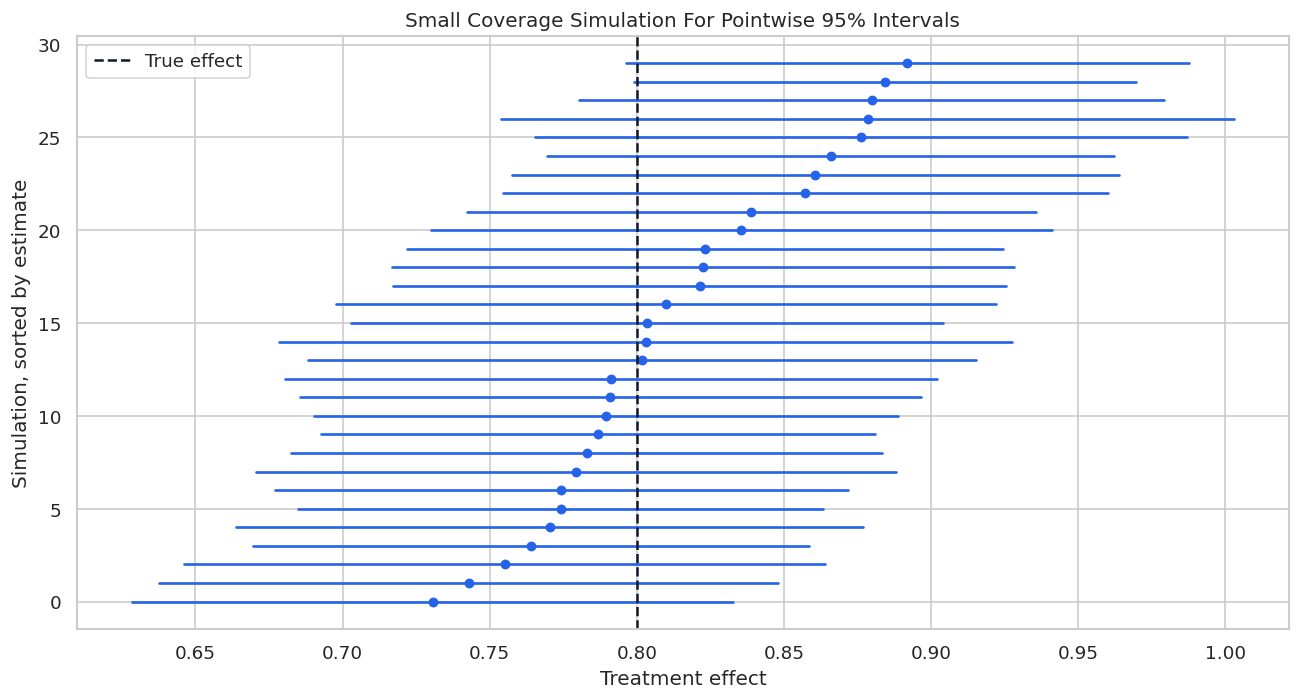

In [18]:
plot_coverage = coverage_simulation.sort_values("theta_hat").reset_index(drop=True)
plot_coverage["ordered_sim"] = np.arange(len(plot_coverage))
plot_coverage["coverage_label"] = np.where(plot_coverage["covers_true"], "covers", "misses")
fig, ax = plt.subplots(figsize=(11, 6))
for _, row in plot_coverage.iterrows():
    color = "#2563eb" if row["covers_true"] else "#dc2626"
    ax.plot([row["ci_lower"], row["ci_upper"]], [row["ordered_sim"], row["ordered_sim"]], color=color, linewidth=1.6)
    ax.scatter(row["theta_hat"], row["ordered_sim"], color=color, s=24)
ax.axvline(coverage_true_theta, color="#111827", linestyle="--", linewidth=1.5, label="True effect")
ax.set_title("Small Coverage Simulation For Pointwise 95% Intervals")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Simulation, sorted by estimate")
ax.legend(loc="best")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_coverage_simulation.png", bbox_inches="tight")
plt.show()


Coverage is a repeated-sampling idea. For one applied interval, the true effect is either inside or outside the interval, although we never observe that status directly. The simulation is here to make the concept concrete.





## Reporting and Takeaways

### Reporting Checklist

This checklist summarizes what should be reported when presenting DoubleML inference results. The emphasis is on clarity: point estimate, uncertainty type, bootstrap settings, and multiple-testing choices should all be visible.


| item | why |
| --- | --- |
| State the estimand and treatment columns | Inference is only meaningful after the target is clear. |
| Report coefficient, standard error, and confidence interval | A point estimate without uncertainty is incomplete. |
| Say whether intervals are pointwise or joint | These intervals answer different reporting questions. |
| Document bootstrap method and number of replications | Joint intervals and Romano-Wolf adjustment depend on bootstrap settings. |
| Use adjusted p-values for multiple treatment tests | Several tests increase the chance of false discoveries. |
| Report nuisance model and cross-fitting choices | Uncertainty is conditional on the fitted DoubleML design. |
| Separate statistical uncertainty from identification uncertainty | Bootstrap cannot fix omitted variables, bad timing, or invalid instruments. |


The last row is the most important. Statistical inference quantifies sampling uncertainty under the design; it does not prove the design is correct.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Reporting and Takeaways

A finished analysis should be easy for another careful reader to review. It should state the causal question, target estimand, identification assumptions, main estimate, diagnostics, sensitivity checks, and remaining limitations in plain language. The goal is a clear analytical conclusion supported by the tables and figures already shown in the lesson.


The lesson now covers the core DoubleML inference workflow: standard errors, pointwise intervals, multiplier bootstrap, joint intervals, adjusted p-values, and reporting discipline.

The implication is practical: the analysis leaves an audit trail, so readers can connect the final claims to the exact tables and figures that support them.
<!-- result-implication-expanded -->


## What Comes Next

The sequence next moves to sensitivity analysis for unobserved confounding, showing how DoubleML represents robustness to omitted confounders and how those sensitivity parameters can be explained clearly.
